Input 4 bits : 1011
I bits       : 10
Q bits       : 11
I amplitude  : 3
Q amplitude  : 1


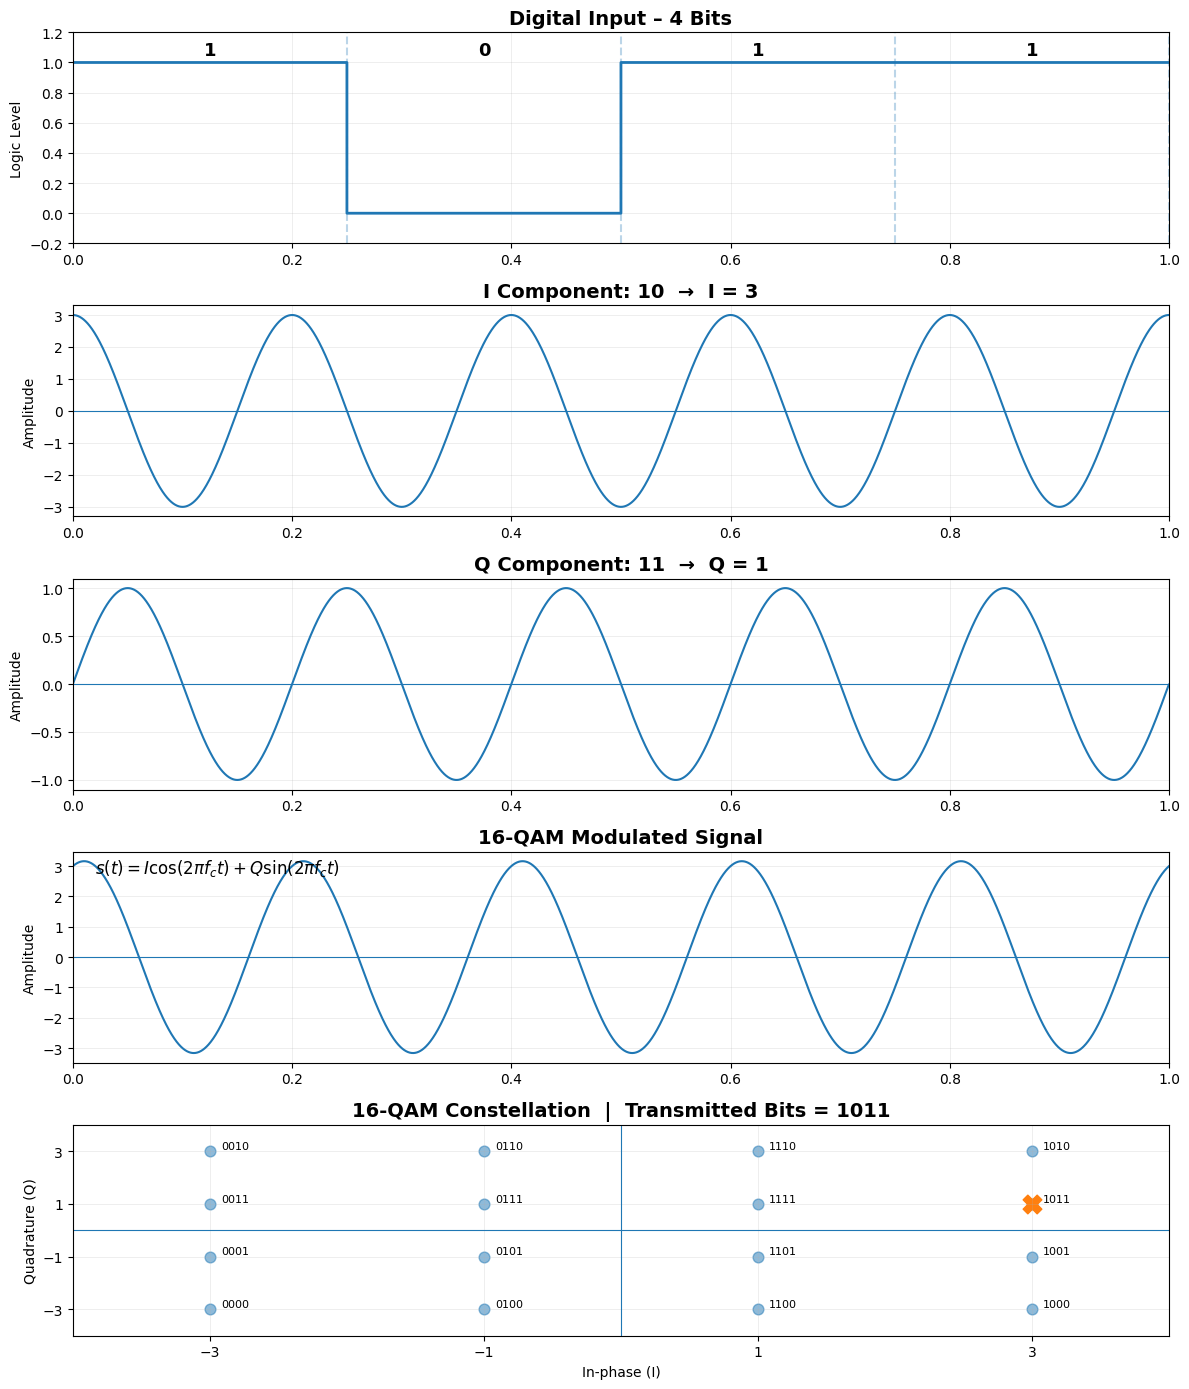


-------------------------------
16-QAM EXPERIMENT
-------------------------------
Input bits       : 1011
I bits           : 10
Q bits           : 11
I amplitude      : 3
Q amplitude      : 1
Selected point   : (3, 1)
-------------------------------


In [14]:

# GENERATION OF 16-QAM USING 4 BITS


import numpy as np
import matplotlib.pyplot as plt


bits = "1011"


if len(bits) != 4 or any(b not in "01" for b in bits):
    raise ValueError("Enter exactly 4 binary bits, for example 1011")

I_bits = bits[:2]
Q_bits = bits[2:]


mapping = {
    "00": -3,
    "01": -1,
    "11": +1,
    "10": +3
}

I_level = mapping[I_bits]
Q_level = mapping[Q_bits]

print("Input 4 bits :", bits)
print("I bits       :", I_bits)
print("Q bits       :", Q_bits)
print("I amplitude  :", I_level)
print("Q amplitude  :", Q_level)

Ts = 1.0
fc = 5.0
fs = 5000

t = np.arange(0, Ts, 1/fs)



carrier_I = np.cos(2 * np.pi * fc * t)

carrier_Q = np.sin(2 * np.pi * fc * t)



I_signal = I_level * carrier_I

Q_signal = Q_level * carrier_Q



qam_signal = I_signal + Q_signal


digital = np.zeros(len(t))

for i, bit in enumerate(bits):

    start = int(i * len(t) / 4)

    if i == 3:
        end = len(t)
    else:
        end = int((i + 1) * len(t) / 4)

    digital[start:end] = int(bit)



levels = [-3, -1, 1, 3]

constellation_I = []
constellation_Q = []

for i_val in levels:
    for q_val in levels:
        constellation_I.append(i_val)
        constellation_Q.append(q_val)



fig = plt.figure(figsize=(12, 14))


ax1 = plt.subplot(5, 1, 1)

ax1.step(t, digital, where='post',
         linewidth=2)

ax1.set_xlim(0, Ts)
ax1.set_ylim(-0.2, 1.2)

ax1.set_title("Digital Input – 4 Bits", fontsize=14, fontweight='bold')
ax1.set_ylabel("Logic Level")
ax1.grid(True, alpha=0.3)


for i in range(5):
    x = i * Ts / 4
    ax1.axvline(x, linestyle='--', alpha=0.3)

for i, bit in enumerate(bits):
    x = (i + 0.5) * Ts / 4
    ax1.text(x, 1.05, bit,
             ha='center',
             fontsize=13,
             fontweight='bold')



ax2 = plt.subplot(5, 1, 2)

ax2.plot(t, I_signal, linewidth=1.5)

ax2.axhline(0, linewidth=0.8)

ax2.set_xlim(0, Ts)

ax2.set_title(
    f"I Component: {I_bits}  →  I = {I_level}",
    fontsize=14,
    fontweight='bold'
)

ax2.set_ylabel("Amplitude")
ax2.grid(True, alpha=0.3)



ax3 = plt.subplot(5, 1, 3)

ax3.plot(t, Q_signal, linewidth=1.5)

ax3.axhline(0, linewidth=0.8)

ax3.set_xlim(0, Ts)

ax3.set_title(
    f"Q Component: {Q_bits}  →  Q = {Q_level}",
    fontsize=14,
    fontweight='bold'
)

ax3.set_ylabel("Amplitude")
ax3.grid(True, alpha=0.3)



ax4 = plt.subplot(5, 1, 4)

ax4.plot(t, qam_signal, linewidth=1.5)

ax4.axhline(0, linewidth=0.8)

ax4.set_xlim(0, Ts)

ax4.set_title(
    "16-QAM Modulated Signal",
    fontsize=14,
    fontweight='bold'
)

ax4.set_ylabel("Amplitude")
ax4.grid(True, alpha=0.3)


ax4.text(
    0.02,
    0.90,
    r"$s(t)=I\cos(2\pi f_ct)+Q\sin(2\pi f_ct)$",
    transform=ax4.transAxes,
    fontsize=12
)


ax5 = plt.subplot(5, 1, 5)


ax5.scatter(
    constellation_I,
    constellation_Q,
    s=60,
    alpha=0.5
)


ax5.scatter(
    I_level,
    Q_level,
    s=180,
    marker='X'
)


ax5.axhline(0, linewidth=0.8)
ax5.axvline(0, linewidth=0.8)

ax5.set_xlim(-4, 4)
ax5.set_ylim(-4, 4)

ax5.set_xticks([-3, -1, 1, 3])
ax5.set_yticks([-3, -1, 1, 3])

ax5.set_xlabel("In-phase (I)")
ax5.set_ylabel("Quadrature (Q)")

ax5.set_title(
    f"16-QAM Constellation  |  Transmitted Bits = {bits}",
    fontsize=14,
    fontweight='bold'
)

ax5.grid(True, alpha=0.3)


for i_val, q_val in zip(constellation_I, constellation_Q):


    reverse_mapping = {v: k for k, v in mapping.items()}

    label = reverse_mapping[i_val] + reverse_mapping[q_val]

    ax5.text(
        i_val + 0.08,
        q_val + 0.08,
        label,
        fontsize=8
    )

plt.tight_layout()
plt.show()


print("\n-------------------------------")
print("16-QAM EXPERIMENT")
print("-------------------------------")
print("Input bits       :", bits)
print("I bits           :", I_bits)
print("Q bits           :", Q_bits)
print("I amplitude      :", I_level)
print("Q amplitude      :", Q_level)
print("Selected point   :", f"({I_level}, {Q_level})")
print("-------------------------------")
